# Case study — immunophenotyping PBMC after cardiac arrest

This notebook is one complete analysis, from an FCS file to a number you could
put in a figure legend, on **real published data**. Nothing is simulated and
nothing is arranged to come out neatly.

If you have never used `ov.flow` before, start here. Every code cell is three or
four lines of `ov.*` calls; the explanation is in the text around them.

## The question

After a cardiac arrest, the body goes through a whole-body inflammatory response.
A natural question is whether the circulating immune compartment looks different
from a healthy person's — specifically, **do the proportions of T cells, and of
the CD4 and CD8 subsets within them, differ between healthy donors and patients
after out-of-hospital cardiac arrest?**

We will answer it, and we will also arrive at an honest statement of how much the
answer is worth, which for six samples is not very much. Getting to a defensible
"here is what we can and cannot say" is the actual skill.

## The data

Peripheral blood mononuclear cells (PBMC) from healthy donors and from patients
after out-of-hospital cardiac arrest, stained with a 14-colour panel and acquired
on a BD LSRFortessa.

> Kim, Edy (2024). *Immunophenotyping of peripheral blood mononuclear cells after
> out-of-hospital cardiac arrest.* Zenodo.
> [10.5281/zenodo.14311616](https://doi.org/10.5281/zenodo.14311616) — CC-BY-4.0

`ov.datasets` downloads it from Zenodo the first time and caches it in `./data`.
We take three files per group, thinned to 25,000 events each, from the
isotype-control arm only — the samples in this experiment also received
antibodies, and mixing treatment arms would confound "healthy versus arrest" with
"drug versus control".

## The plan

1. **Read** the file and see what is in it
2. **Compensate** — undo the optical crosstalk between detectors
3. **Fit the display scales** to this instrument and this data
4. **Build a gating strategy** — the sequence of decisions that isolates T cells
5. **Look at it**, because a gate you have not seen is a gate you cannot defend
6. **Check every sample separately** — this is where the surprise is
7. **Answer the question**, with the caveat it deserves
8. **Save the strategy** so somebody else can re-run exactly this

## 1. Read

An FCS file becomes an `AnnData`: one row per **event** (a cell passing the
laser), one column per **channel** (a detector). `ov.io.read_fcs` does the
reading — it is I/O, so it lives in `ov.io`, not in `ov.flow`.

In [1]:
import omicverse as ov

ov.style()          # omicverse's plotting defaults — call once, before plotting

adata = ov.datasets.flow_pbmc_fortessa(n_per_group=3, max_events=25000)
adata

/Users/fernandozeng/miniforge3/envs/omictest/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.4   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

🔍 Downloading data to ./data/96_Healthy_Anti-Nectin2_Isotype_3.fcs
⚠️ File ./data/96_Healthy_Anti-Nectin2_Isotype_3.fcs already exists
🔍 Downloading data to ./data/97_Healthy_Anti-Nectin2_Isotype_4.fcs
⚠️ File ./data/97_Healthy_Anti-Nectin2_Isotype_4.fcs already exists


🔍 Downloading data to ./data/94_Healthy_Anti-Nectin2_Isotype_1.fcs
⚠️ File ./data/94_Healthy_Anti-Nectin2_Isotype_1.fcs already exists
🔍 Downloading data to ./data/108_CA_Anti-Nectin2_Isotype_3.fcs
⚠️ File ./data/108_CA_Anti-Nectin2_Isotype_3.fcs already exists
🔍 Downloading data to ./data/110_CA_Anti-Nectin2_Isotype_5.fcs
⚠️ File ./data/110_CA_Anti-Nectin2_Isotype_5.fcs already exists


🔍 Downloading data to ./data/106_CA_Anti-Nectin2_Isotype_1.fcs
⚠️ File ./data/106_CA_Anti-Nectin2_Isotype_1.fcs already exists
150,000 events x 16 channels from 6 files
Kim, Edy (2024). Immunophenotyping of peripheral blood mononuclear cells after out-of-hospital cardiac arrest. Zenodo. https://doi.org/10.5281/zenodo.14311616 (CC-BY-4.0)


AnnData object with n_obs × n_vars = 150000 × 16
    obs: 'sample', 'group', 'source_file'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnG', 'PnR'
    uns: 'fcs', 'dataset'

`obs` carries which file and which group each event came from. `var`
carries the two names every cytometry channel has — the **detector** the machine
recorded (`FITC-A`) and the **marker** the antibody on it stains (`CD3`). You can
use either name anywhere in `ov.flow`.

The `PnR` column is the *top of scale*: the largest value this instrument can
report. It matters later.

In [2]:
adata.var[["channel", "marker", "PnR"]]

                     channel     marker       PnR
FSC-A                  FSC-A             262144.0
SSC-A                  SSC-A             262144.0
CD3                   FITC-A        CD3  262144.0
Tim3                    PE-A       Tim3  262144.0
Nectin2        PerCP-Cy5-5-A    Nectin2  262144.0
IL10                PE-Cy7-A       IL10  262144.0
IFNg                   APC-A       IFNg  262144.0
TNFa               APC-Cy7-A       TNFa  262144.0
CD4                  BV421-A        CD4  262144.0
CD8                 AmCyan-A        CD8  262144.0
TIGIT                BV605-A      TIGIT  262144.0
CD14                 BV650-A       CD14  262144.0
CD16                 BV711-A       CD16  262144.0
CD56                 BV786-A       CD56  262144.0
LIVE DEAD  Alexa Fluor 350-A  LIVE DEAD  262144.0
Time                    Time             262144.0

## 2. Compensate

Fluorochromes are not tidy. Each one emits light over a broad spectrum, so the
detector meant for CD4 also picks up some of the light from the CD3 dye. The
effect is called **spillover**, and without correcting it a bright CD3 cell looks
faintly CD4-positive purely as an optical artefact.

The instrument measures how much each dye leaks into each detector and writes it
into the file as a matrix. Look at it first.

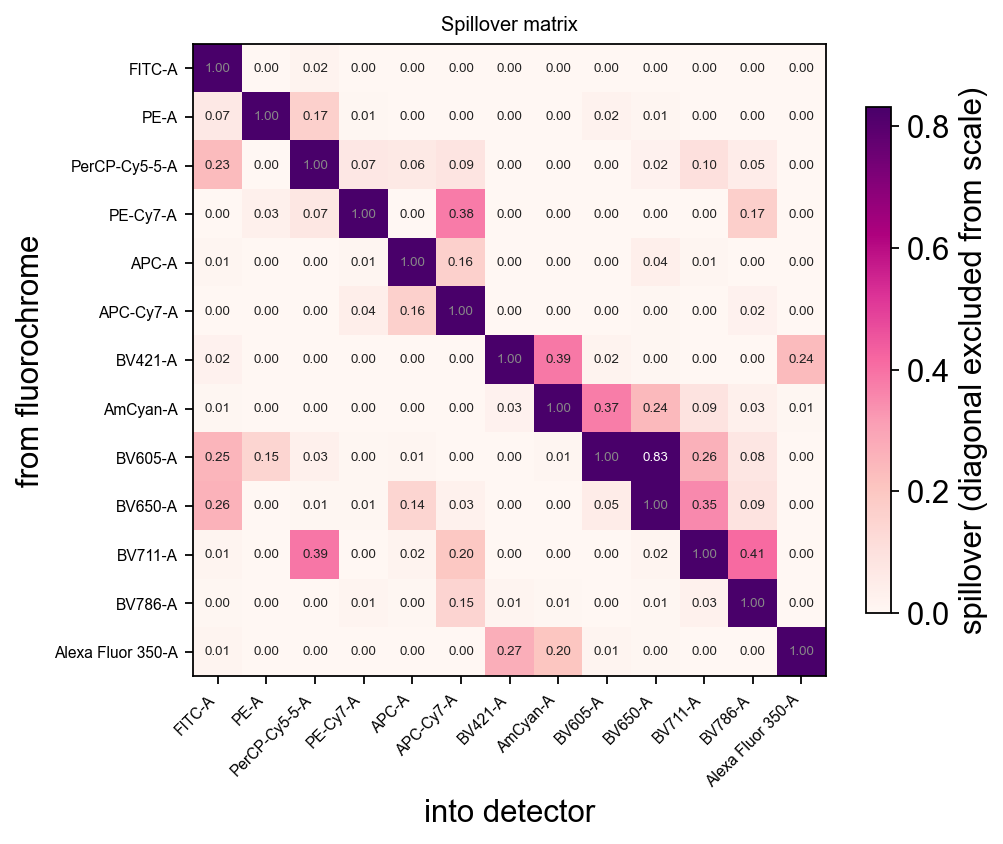

In [3]:
ov.flow.spillover_heatmap(adata, figsize=(6.4, 5.2))
None

Rows are fluorochromes, columns are detectors. The diagonal is 1.0 by
definition and is excluded from the colour scale — leaving it in would squash
every other value into the pale end. Some of these are large: the worst pair
leaks 83%, meaning that detector sees almost as much of the wrong dye as of its
own.

`compensate` inverts that matrix and applies it. It reads the file's own
`$SPILLOVER` keyword, keeps the uncorrected values as a layer, and refuses to run
twice — compensating twice is silently destructive because the numbers stay
plausible.

In [4]:
ov.flow.compensate(adata)
adata.uns["flow"]["compensated"], list(adata.layers)

(True, ['uncompensated'])

## 3. Fit the display scales

Cytometry data spans four or five decades, so it is never plotted linearly. But
after compensation a lot of values are **negative** — subtracting spillover from
a dim cell easily lands below zero — and a log axis cannot show a negative
number at all. Those events would silently vanish, including exactly the dim
events a threshold has to be drawn between.

The field's answer is a *biexponential* scale (logicle): linear near zero,
logarithmic further out, so the whole range fits on one axis. It has a parameter
`W` controlling how wide the linear part is, and the right value depends on how
noisy this particular detector was.

`auto_transforms` handles both things that are easy to get wrong: it reads each
channel's top of scale from `$PnR` rather than assuming a constant, and it fits
`W` to each channel's own negative values using the published estimator. Scatter
channels get a plain linear scale, since they have no negatives to accommodate.

In [5]:
tr = ov.flow.auto_transforms(adata)

{name: f"{type(t).__name__}(t={t.t:,.0f}"
       + (f", w={t.w:.2f})" if hasattr(t, "w") else ")")
 for name, t in list(tr.items())[:6]}

{'FSC-A': 'Linear(t=262,144)',
 'SSC-A': 'Linear(t=262,144)',
 'CD3': 'Logicle(t=262,144, w=1.38)',
 'Tim3': 'Logicle(t=262,144, w=1.31)',
 'Nectin2': 'Logicle(t=262,144, w=1.85)',
 'IL10': 'Logicle(t=262,144, w=0.61)'}

## 4. Build the gating strategy

**Gating** is cytometry's core operation: a sequence of regions drawn on
two-parameter plots, each one applied only to the events the previous one kept.
It is how you isolate a population when there is no single marker that defines
it.

Our sequence:

| Step | Plot | Keeps | Why |
|---|---|---|---|
| `Cells` | FSC-A × SSC-A | intact cells | size and granularity separate real cells from debris |
| `Live` | viability dye | living cells | a dead cell leaks dye in and stains bright |
| `T cells` | CD3 | T lymphocytes | CD3 is the defining T-cell marker |
| `CD4/CD8` | CD4 × CD8 | four subsets | the two main T-cell lineages, plus the two "neither" and "both" corners |

Three things about how this is written:

- **Thresholds are in data units.** `above=400` means 400 units of CD3
  fluorescence — the number you would read off the axis. The gate stores its
  boundary internally on the transformed scale, and `ov.flow.threshold` does that
  conversion for you. Typing the transformed number by hand is the classic way a
  gate silently ends up somewhere else.
- **Every gate carries its transform.** That is what makes it re-applicable to
  another file, and savable.
- **`parent=` builds the tree.** Each gate is evaluated only on its parent's
  events, so `T cells` means "CD3-positive *among live cells*".

In [6]:
gs = ov.flow.GatingStrategy("PBMC immunophenotyping")

gs.add_gate(ov.flow.polygon(
    "Cells", "FSC-A", "SSC-A",
    [(28000, 2000), (28000, 72000), (95000, 130000),
     (165000, 130000), (165000, 30000), (80000, 2000)], transforms=tr))

gs.add_gate(ov.flow.threshold("Live", "LIVE DEAD", below=400, transforms=tr),
            parent="Cells")

gs.add_gate(ov.flow.threshold("T cells", "CD3", above=400, transforms=tr),
            parent="Live")

gs.add_gate(ov.flow.quadrant("CD4/CD8", "CD4", "CD8", 120, 250, transforms=tr,
                             names=("DN T", "CD4 T", "CD8 T", "DP T")),
            parent="T cells")

print(gs.tree())

root
  └ Cells
    └ Live
      └ T cells
        └ CD4/CD8
        └ DN T
        └ CD4 T
        └ CD8 T
        └ DP T


Applying the strategy walks that tree and returns one boolean mask per
population.

In [7]:
res = gs.apply(adata)
res.stats()

  population   parent  count  parent_count  freq_parent  freq_total  low_n
0      CD4 T  T cells  23177         59681     0.388348    0.154513  False
1    CD4/CD8  T cells  59681         59681     1.000000    0.397873  False
2      CD8 T  T cells  19440         59681     0.325732    0.129600  False
3      Cells     root  91031        150000     0.606873    0.606873  False
4       DN T  T cells  16841         59681     0.282184    0.112273  False
5       DP T  T cells    223         59681     0.003737    0.001487  False
6       Live    Cells  90210         91031     0.990981    0.601400  False
7    T cells     Live  59681         90210     0.661579    0.397873  False

Reading this table:

- **`count`** — events in the population
- **`parent`** / **`parent_count`** — what it is a fraction *of*
- **`freq_parent`** — the number people actually report ("31% of T cells"). It is
  meaningless without its denominator, which is why the parent is named in its
  own column
- **`low_n`** — flags populations too small for the percentage to mean anything.
  A frequency measured on 30 events has a 95% confidence interval of roughly
  ±18 percentage points; printing it to one decimal place is false precision

## 5. Look at the gates

**Do not skip this.** A statistics table cannot tell you whether a gate is in the
right place — only the picture can. `plot_strategy` draws the whole sequence
from the strategy object: one panel per gate, each on its parent's events, each
in that gate's own scale.

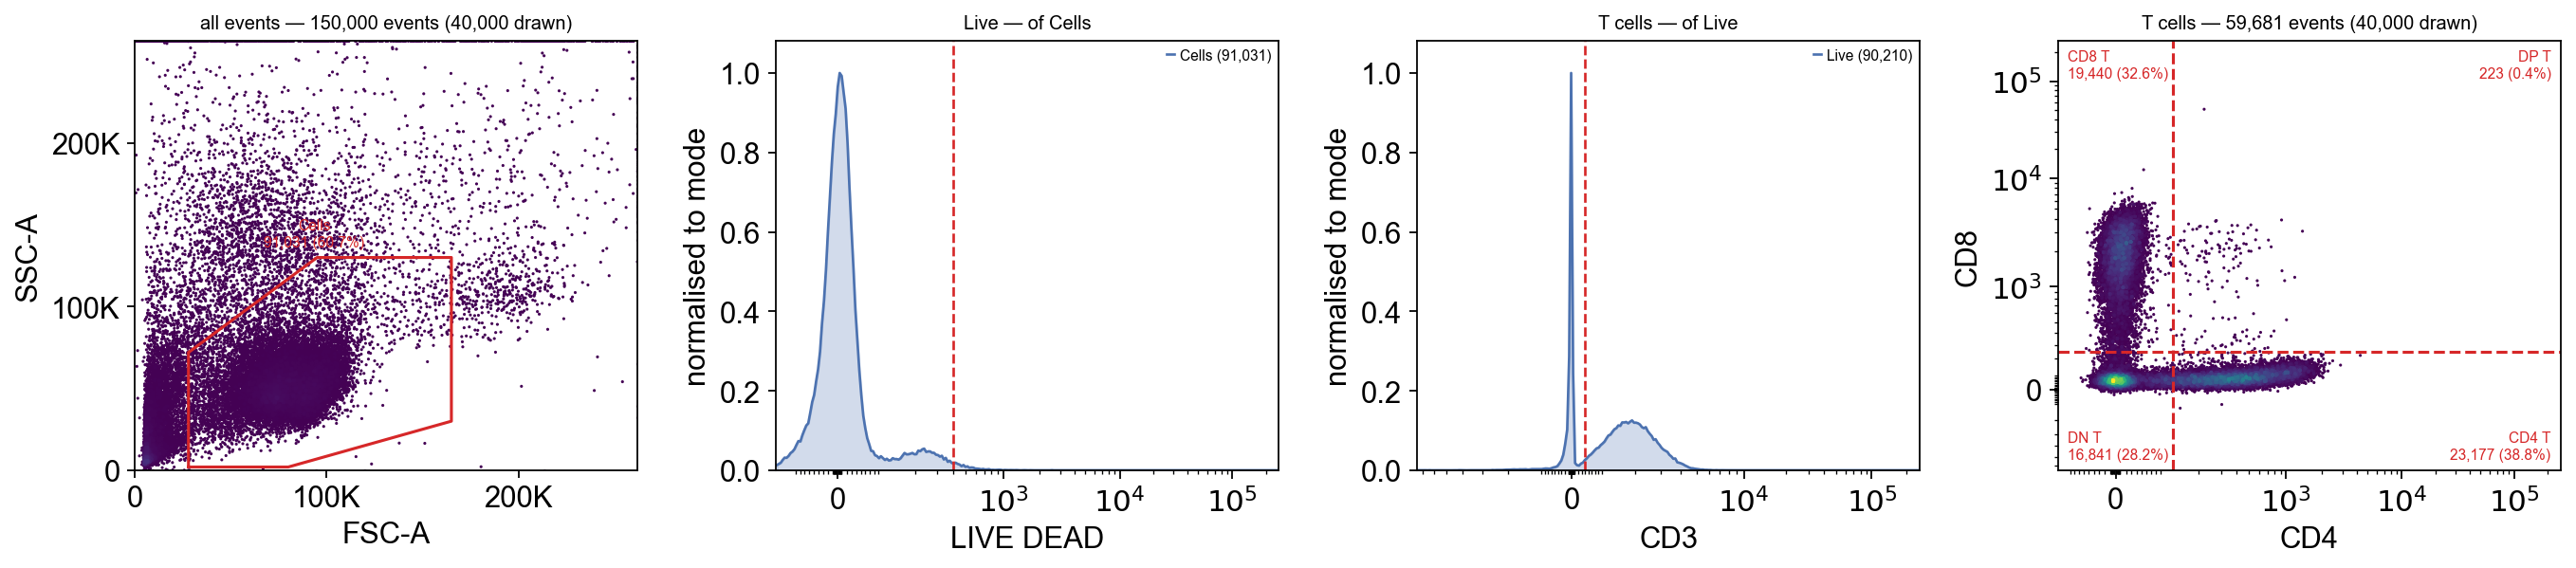

In [8]:
ov.flow.plot_strategy(adata, gs, res, transforms=tr, ncols=4)
None

What to check, panel by panel:

1. **FSC × SSC** — the polygon should contain the dense cloud of cells and
   exclude the debris pressed against the bottom-left corner.
2. **Viability** — the threshold should sit in the valley to the right of the big
   negative peak. Here it removes very little, which tells you the sample was
   fresh. That is worth saying out loud rather than implying the gate did work it
   did not do.
3. **CD3** — two clear humps, threshold between them.
4. **CD4 × CD8** — the two arms should be visible and the dividers should sit in
   the gaps.

The hierarchy view puts the same numbers on the tree, which is the fastest way to
see where events were lost:

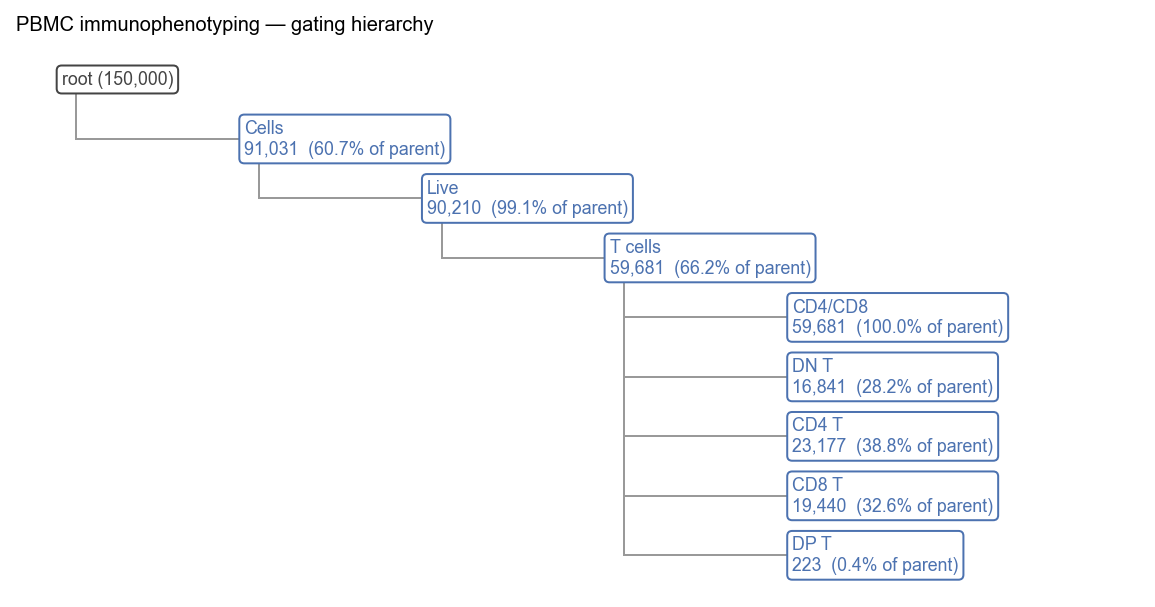

In [9]:
ov.flow.hierarchy(gs, result=res, figsize=(9, 4.5))
None

## 6. Check every sample separately

Here is the step that matters most and is skipped most often.

Everything above pooled six files into one matrix. That is fine for drawing
gates, but **a frequency computed on pooled data is an average, and an average
hides a broken sample.** `batch_stats` re-runs the same strategy on each sample
independently and returns one row per sample per population.

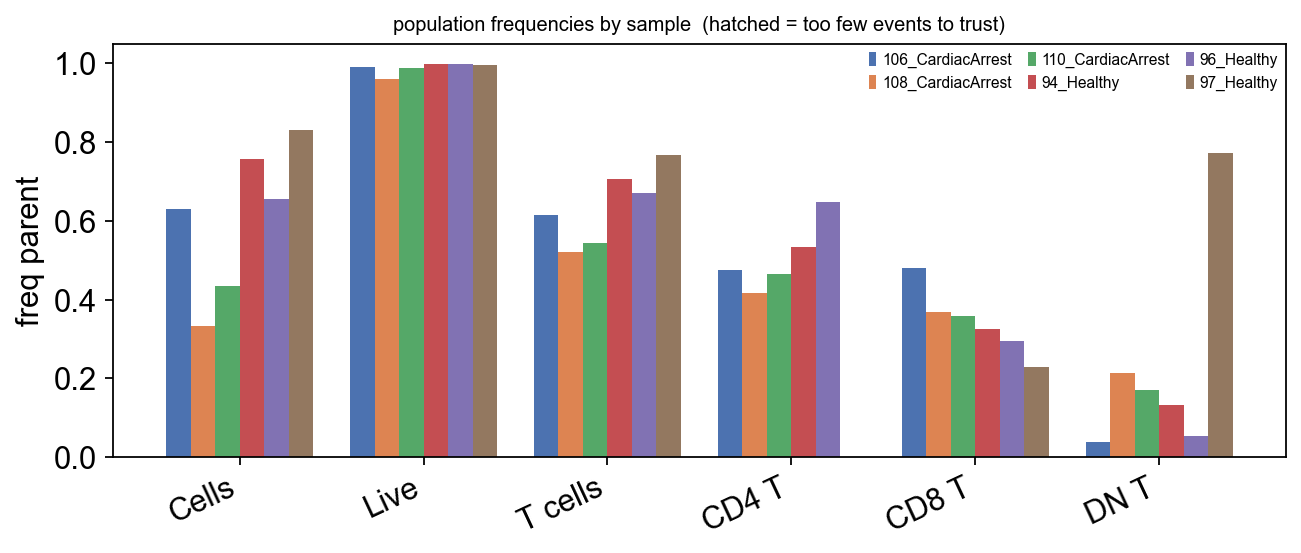

In [10]:
stats = ov.flow.batch_stats(adata, gs, groupby="sample")
ov.flow.plot_batch(stats, populations=["Cells", "Live", "T cells",
                                       "CD4 T", "CD8 T", "DN T"])
None

Look at the `DN T` group — double-negative T cells, which are CD3+ but
neither CD4 nor CD8. In healthy blood they are 1–5% of T cells. Here one bar is
enormous.

Sorted, so there is no ambiguity about which sample it is:

In [11]:
stats.query("population == 'DN T'").sort_values("freq_parent")[
    ["sample", "count", "parent_count", "freq_parent", "low_n"]]

               sample  count  parent_count  freq_parent  low_n
4   106_CardiacArrest    377          9596     0.039287  False
36         96_Healthy    584         10941     0.053377  False
28         94_Healthy   1782         13315     0.133834  False
20  110_CardiacArrest    995          5820     0.170962  False
12  108_CardiacArrest    894          4160     0.214904  False
44         97_Healthy  12209         15849     0.770333  False

Five samples span roughly 4% to 22%. That is already higher than
the 1–5% quoted for resting blood, and there is a reason: these are PBMC in an
*in vitro* assay, and activated T cells downmodulate surface CD4 and CD8. A
stimulation experiment producing a fifth of its T cells in the double-negative
corner is unremarkable.

The sixth sample is at **77%**, and that is not the same thing. A genuine 77% DN
population would be a case report. What it looks like is a **failed or weak
CD4/CD8 stain in that one tube**: if neither antibody bound properly, every T
cell lands in the double-negative corner regardless of what it really is.

The confirming detail is in the same table, one population over:

In [12]:
stats.query("population == 'CD4 T'").sort_values("count")[
    ["sample", "count", "parent_count", "freq_parent", "low_n"]]

               sample  count  parent_count  freq_parent  low_n
40         97_Healthy      3         15849     0.000189   True
8   108_CardiacArrest   1733          4160     0.416587  False
16  110_CardiacArrest   2711          5820     0.465808  False
0   106_CardiacArrest   4549          9596     0.474052  False
32         96_Healthy   7084         10941     0.647473  False
24         94_Healthy   7097         13315     0.533008  False

That sample has **three** CD4 T cells out of nearly sixteen thousand
T cells, and `low_n` flags it. Three is not a small population; three is an
antibody that did not bind. No biological story produces a donor with three CD4
T cells who is otherwise unremarkable.

Two things worth taking from this:

**The pooled number was a fiction.** Averaged over six files the DN frequency
looks moderately elevated, which is exactly the kind of number that gets written
into a paper as a finding. Only the per-sample view shows it is one tube.

**Do not fix it by moving the gate.** The tempting response is to lower the CD4
threshold until the number looks reasonable. That would be fitting the analysis
to the answer you wanted, and it would corrupt the five samples that were fine.
The gate is not wrong; the sample is.

## 7. Exclude it — visibly

The defensible response is to exclude the sample and **say that you did**, with
the reason. Never silently.

excluded for failed CD4/CD8 staining: ['97_Healthy']


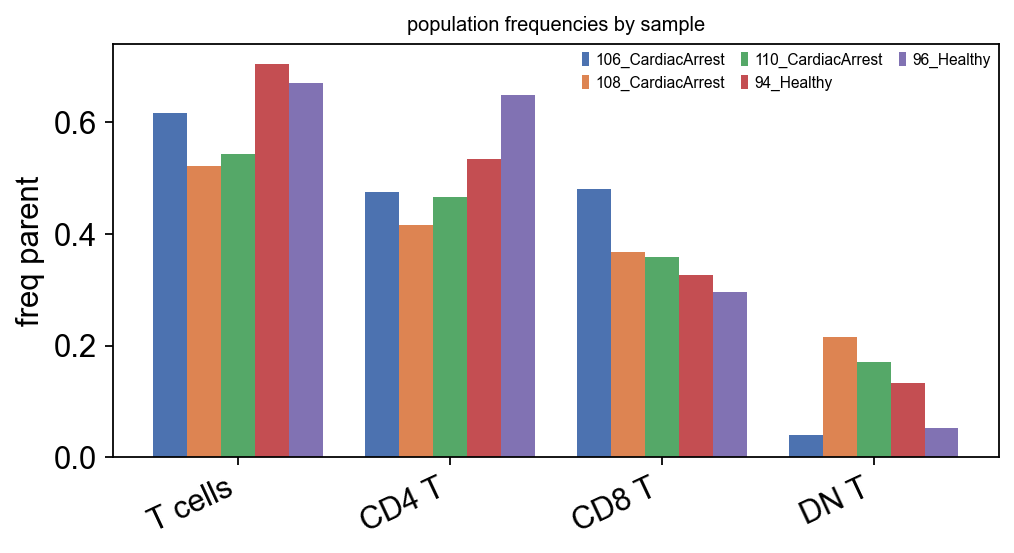

In [13]:
bad = stats.query("population == 'DN T' and freq_parent > 0.5")["sample"].tolist()
print("excluded for failed CD4/CD8 staining:", bad)

clean = adata[~adata.obs["sample"].isin(bad)].copy()
stats_clean = ov.flow.batch_stats(clean, gs, groupby="sample")
ov.flow.plot_batch(stats_clean, populations=["T cells", "CD4 T", "CD8 T", "DN T"])
None

Now the DN bars are where they should be and the CD4/CD8 split is
consistent across samples.

## 8. The answer

Group the surviving samples and compare.

In [14]:
groups = clean.obs.drop_duplicates("sample").set_index("sample")["group"]
summary = stats_clean.query(
    "population in ['T cells', 'CD4 T', 'CD8 T', 'NK']").copy()
summary["group"] = summary["sample"].map(groups)
summary.groupby(["population", "group"], observed=True)["freq_parent"].agg(
    ["mean", "std", "count"]).round(3)

                           mean    std  count
population group                             
CD4 T      CardiacArrest  0.452  0.031      3
           Healthy        0.590  0.081      2
CD8 T      CardiacArrest  0.402  0.068      3
           Healthy        0.311  0.022      2
T cells    CardiacArrest  0.560  0.050      3
           Healthy        0.687  0.024      2

**What this shows.** All three numbers move in the same direction:
the cardiac-arrest samples have a smaller T-cell fraction, a smaller CD4
proportion within it, and a larger CD8 proportion — that is, a lower CD4:CD8
ratio. The gaps between the means (roughly 13, 14 and 9 percentage points) are
larger than the within-group spreads, so this is not obviously noise.

**What it does not show.** It is not a result, for reasons that have nothing to
do with the analysis:

- **n = 3 versus n = 2.** The healthy group lost a sample to the QC exclusion.
  Two donors cannot establish a group mean, and no test on these numbers would
  mean anything — which is why none is run here.
- **Donor-to-donor variation in immunophenotyping is large**, often larger than
  the effects people look for. Three donors cannot separate the two.
- **The samples are not matched** for age, sex, time since arrest, or any of the
  clinical covariates that move lymphocyte counts.

So: a direction consistent with what is described after severe systemic
inflammation, on far too few samples to claim it. The honest write-up is "in
these six donors, of whom one was excluded for a staining failure, the
cardiac-arrest samples trended toward a lower CD4:CD8 ratio" — and then you go
and run it on the other 26 files.

This notebook is a demonstration of the *method*. Its most important output is
the QC finding in step 6, not the group comparison.

If you want to go further, the Zenodo record has 32 files — pass `n_per_group=3`
and the other treatment arms, or work from the full record.

## 9. Save the strategy

The strategy is an object, not a sequence of clicks, so it can be written to
**Gating-ML 2.0** — the ISAC interchange standard that FlowJo, Cytobank and
flowCore all read. This is what makes the analysis reproducible by someone else,
in software you do not control.

In [15]:
ov.flow.write_gatingml(gs, "pbmc_strategy.xml")
reloaded = ov.flow.read_gatingml("pbmc_strategy.xml")

mine = gs.apply(clean.copy(), write_obs=False).stats().set_index("population")["count"]
theirs = reloaded.apply(clean.copy(), write_obs=False).stats().set_index("population")["count"]
print(f"{len(reloaded)} gates read back")
print("every population count identical after the round trip:", mine.equals(theirs))

4 gates read back
every population count identical after the round trip: True


## 10. A cross-check with clustering

Manual gating encodes what you already expect to find. Unsupervised clustering
does not, so running it is a way of asking whether the gates missed something.

`flowsom` is the cytometry standard. Run it on the **gated** T cells — clustering
before gating lets debris and dead cells form their own clusters and dominate the
result.

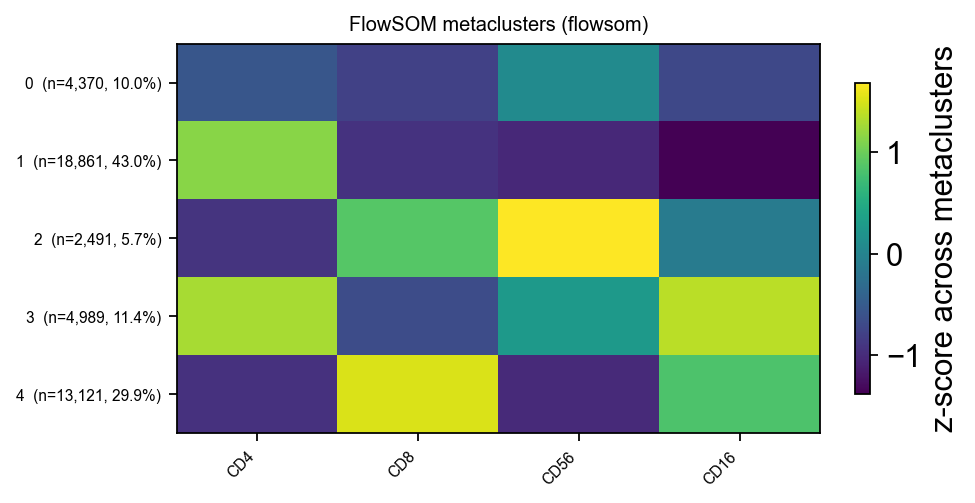

In [16]:
res_clean = gs.apply(clean, write_obs=False)
t_cells = clean[res_clean.masks["T cells"]].copy()

ov.flow.apply_transforms(t_cells)          # cluster on the display scale, not raw
ov.flow.flowsom(t_cells, n_clusters=5, layer="transformed",
                markers=["CD4", "CD8", "CD56", "CD16"], random_state=0)
ov.flow.flowsom_heatmap(t_cells, layer="transformed",
                        markers=["CD4", "CD8", "CD56", "CD16"], figsize=(5.6, 3.2))
None

Each row is a metacluster, each column a marker, colour is the z-scored
mean. If the CD4-high and CD8-high clusters line up with the gates you drew, the
gating agrees with an unsupervised view of the same events — which is a
meaningful check, because the clustering had no idea what you were looking for.

## Summary — the whole analysis

```python
adata = ov.datasets.flow_pbmc_fortessa(n_per_group=3)   # 1. read
ov.flow.compensate(adata)                               # 2. compensate
tr = ov.flow.auto_transforms(adata)                     # 3. fit the scales

gs = ov.flow.GatingStrategy("PBMC")                     # 4. gate
gs.add_gate(ov.flow.polygon("Cells", "FSC-A", "SSC-A", verts, transforms=tr))
gs.add_gate(ov.flow.threshold("Live", "LIVE DEAD", below=400, transforms=tr),
            parent="Cells")
gs.add_gate(ov.flow.threshold("T cells", "CD3", above=400, transforms=tr),
            parent="Live")
gs.add_gate(ov.flow.quadrant("CD4/CD8", "CD4", "CD8", 120, 250, transforms=tr),
            parent="T cells")
res = gs.apply(adata)

ov.flow.plot_strategy(adata, gs, res, transforms=tr)    # 5. look at it
stats = ov.flow.batch_stats(adata, gs, groupby="sample")# 6. per sample
ov.flow.plot_batch(stats)
ov.flow.write_gatingml(gs, "strategy.xml")              # 9. save it

ov.flow.apply_transforms(t_cells)                       # 10. cross-check
ov.flow.flowsom(t_cells, n_clusters=5, layer="transformed", markers=[...])
```

**The three habits worth taking away**

1. **Look at every gate.** A table cannot tell you a gate is misplaced.
2. **Never report a pooled frequency without looking at the spread.** One failed
   tube moves an average a long way, and the average is what gets published.
3. **When a number is implausible, suspect the sample before adjusting the
   gate.** Moving a threshold until the answer looks right is fitting the
   analysis to the conclusion.
4. **Separate the direction from the claim.** Six samples can show you a
   direction. They cannot support a result, and saying so costs nothing.

### Where to go next

- [Reading, compensation and display scales](t_flow_01_reading_and_compensation.ipynb) — the mechanics of steps 1–3, on simulated data where the right answer is known
- [Gates and the strategy tree](t_flow_02_gating.ipynb) — all five gate geometries, back-gating, boolean gates
- [Saving and re-applying a strategy](t_flow_03_gatingml.ipynb) — Gating-ML in depth, diffing two strategies
- [FlowSOM](t_flow_04_flowsom.ipynb) — clustering, and the order that makes it trustworthy
- [The whole module on real data](t_flow_05_real_data.ipynb) — the same datasets with the instrument-level detail (`$PnR`, fitting `W`, spectral versus conventional)